# NAMA = Destiana Safitri
# NIM = 202231121

## 1. Import Library

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

## 2. Membaca Dataset

In [5]:
df = pd.read_csv('clustering.csv')
# Menampilkan dataset
df

,title,type,genres,releaseYear,imdbId,imdbAverageRating,imdbNumVotes,availableCountries
0,Forrest Gump,movie,"Drama, Romance",1994.0,tt0109830,8.8,2319813.0,MX
1,The Fifth Element,movie,"Action, Adventure, Sci-Fi",1997.0,tt0119116,7.6,517488.0,"AT, CH, DE"
2,Kill Bill: Vol. 1,movie,"Action, Crime, Thriller",2003.0,tt0266697,8.2,1222943.0,"AE, AL, AO, AT, AU, AZ, BG, BH, BY, CA, CI, CM..."
3,Jarhead,movie,"Biography, Drama, War",2005.0,tt0418763,7.0,211759.0,"AD, AE, AG, AL, AO, AT, AZ, BA, BG, BH, BM, BR..."
4,Unforgiven,movie,"Drama, Western",1992.0,tt0105695,8.2,444283.0,"AU, BA, BG, CZ, HR, HU, MD, ME, MK, NZ, PL, RO..."
...,...,...,...,...,...,...,...,...
20134,NaN,tv,NaN,2024.0,NaN,NaN,NaN,"AL, AZ, BA, BG, BY, CY, EE, FR, GF, HU, IT, LT..."
20135,NaN,tv,Drama,2024.0,NaN,NaN,NaN,"AO, CI, CM, CV, GH, GQ, KE, MG, ML, MU, MZ, NE..."
20136,NaN,tv,"Animation, Action & Adventure",2016.0,NaN,NaN,NaN,"FJ, HK, ID, IN, JP, KR, MU, MY, PH, PK, SG, TH..."
20137,NaN,tv,NaN,NaN,NaN,NaN,NaN,"FJ, HK, ID, IN, JP, KR, MU, MY, PH, PK, SG, TH..."


In [6]:
# Mengambil 1000 data secara random
df_sampled = df.sample(n=1000, random_state=50)

In [7]:
df_sampled

,title,type,genres,releaseYear,imdbId,imdbAverageRating,imdbNumVotes,availableCountries
19537,Luz: The Light of the Heart,tv,"Adventure, Comedy, Family",2024.0,tt27760092,7.0,192.0,"AD, AE, AG, AL, AO, AR, AT, AU, AZ, BA, BB, BE..."
16104,Unsolved Mysteries,tv,"Crime, Documentary, Mystery",2020.0,tt9642938,7.3,13365.0,"AD, AE, AG, AL, AO, AR, AT, AU, AZ, BA, BB, BE..."
19983,NaN,tv,Reality,2024.0,NaN,NaN,NaN,KR
1144,All or Nothing,movie,Drama,2002.0,tt0286261,7.5,11635.0,"BG, GR, IS, NL, PT"
5889,Richard Jewell,movie,"Biography, Crime, Drama",2019.0,tt3513548,7.5,100413.0,"AU, NZ"
...,...,...,...,...,...,...,...,...
13250,Maali Mama,movie,Comedy,2022.0,tt26315943,3.1,15.0,"AE, AG, AL, AZ, BA, BE, BG, BH, BM, BS, BY, CA..."
659,The Karate Kid Part II,movie,"Action, Family, Sport",1986.0,tt0091326,6.1,101506.0,"AD, AE, AG, AL, AO, AT, AU, AZ, BA, BE, BG, BH..."
7891,Legends,movie,"Comedy, Drama, Music",2017.0,tt6084472,6.3,815.0,"AD, ES, GI"
1899,Bloody Tie,movie,"Action, Crime, Thriller",2006.0,tt0816437,6.2,810.0,KR


## 3. Pemilihan Fitur

In [8]:
df_clustering = df_sampled[['imdbAverageRating', 'imdbNumVotes']].copy()

In [9]:
# Pengecekan terhadap missing values
print("Jumlah Missing Values sebelum penanganan:")
print(df_clustering.isnull().sum())

Jumlah Missing Values sebelum penanganan:
imdbAverageRating    72
imdbNumVotes         72
dtype: int64


In [10]:
# Menangani kolom yang missing values menggunakan mean
df_clustering['imdbAverageRating'] = df_clustering['imdbAverageRating'].fillna(df_clustering['imdbAverageRating'].mean())
df_clustering['imdbNumVotes'] = df_clustering['imdbNumVotes'].fillna(df_clustering['imdbNumVotes'].mean())

# Mengecek kembali
print("Missing values setelah penanganan:")
print(df_clustering.isnull().sum())

Missing values setelah penanganan:
imdbAverageRating    0
imdbNumVotes         0
dtype: int64


## 4. Praproses Data (Standardisasi)

In [11]:
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_clustering)

## 5. K-Means Clustering

In [12]:
kmeans = KMeans(n_clusters=2, n_init=10, random_state=42)
df_sampled['Cluster'] = kmeans.fit_predict(df_scaled)

## 6. Visualisai hasil clustering

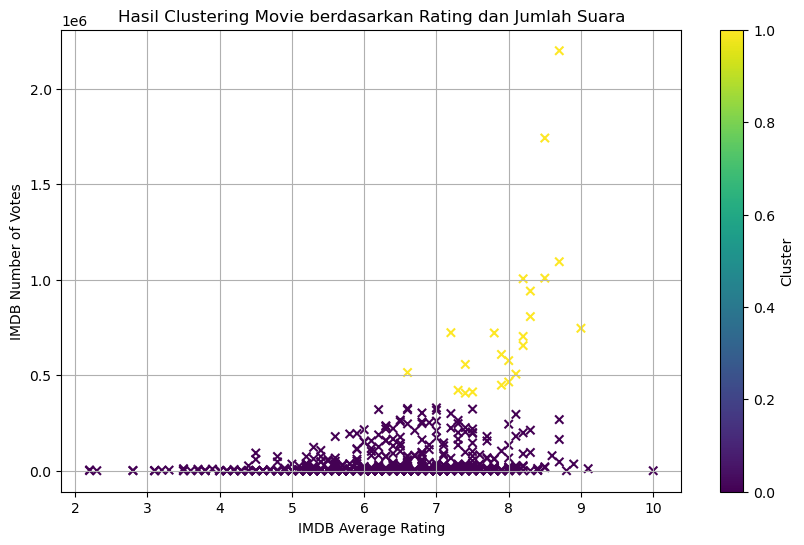

In [13]:
plt.figure(figsize=(10, 6))
plt.scatter(df_sampled['imdbAverageRating'], df_sampled['imdbNumVotes'], 
            c=df_sampled['Cluster'], cmap='viridis', marker='x')
plt.xlabel('IMDB Average Rating')
plt.ylabel('IMDB Number of Votes')
plt.title('Hasil Clustering Movie berdasarkan Rating dan Jumlah Suara')
plt.colorbar(label='Cluster')
plt.grid(True)
plt.show()

In [14]:
# Menampilkan informasi jumlah anggota tiap cluster
cluster_counts = df_sampled['Cluster'].value_counts()
print("\nJumlah anggota tiap cluster:")
print(cluster_counts)


Jumlah anggota tiap cluster:
Cluster
0    978
1     22
Name: count, dtype: int64


In [15]:
cluster_1 = df_sampled[df_sampled['Cluster'] == 0]
cluster_1

,title,type,genres,releaseYear,imdbId,imdbAverageRating,imdbNumVotes,availableCountries,Cluster
19537,Luz: The Light of the Heart,tv,"Adventure, Comedy, Family",2024.0,tt27760092,7.0,192.0,"AD, AE, AG, AL, AO, AR, AT, AU, AZ, BA, BB, BE...",0
16104,Unsolved Mysteries,tv,"Crime, Documentary, Mystery",2020.0,tt9642938,7.3,13365.0,"AD, AE, AG, AL, AO, AR, AT, AU, AZ, BA, BB, BE...",0
19983,NaN,tv,Reality,2024.0,NaN,NaN,NaN,KR,0
1144,All or Nothing,movie,Drama,2002.0,tt0286261,7.5,11635.0,"BG, GR, IS, NL, PT",0
5889,Richard Jewell,movie,"Biography, Crime, Drama",2019.0,tt3513548,7.5,100413.0,"AU, NZ",0
...,...,...,...,...,...,...,...,...,...
13250,Maali Mama,movie,Comedy,2022.0,tt26315943,3.1,15.0,"AE, AG, AL, AZ, BA, BE, BG, BH, BM, BS, BY, CA...",0
659,The Karate Kid Part II,movie,"Action, Family, Sport",1986.0,tt0091326,6.1,101506.0,"AD, AE, AG, AL, AO, AT, AU, AZ, BA, BE, BG, BH...",0
7891,Legends,movie,"Comedy, Drama, Music",2017.0,tt6084472,6.3,815.0,"AD, ES, GI",0
1899,Bloody Tie,movie,"Action, Crime, Thriller",2006.0,tt0816437,6.2,810.0,KR,0


In [16]:
print("\nData anggota Cluster 2:")
cluster_2 = df_sampled[df_sampled['Cluster'] == 1]
cluster_2


Data anggota Cluster 2:


,title,type,genres,releaseYear,imdbId,imdbAverageRating,imdbNumVotes,availableCountries,Cluster
2907,Drive,movie,"Action, Drama",2011.0,tt0780504,7.8,721034.0,"GB, GG, IE, KR, MT",1
4667,Interstellar,movie,"Adventure, Drama, Sci-Fi",2014.0,tt0816692,8.7,2198506.0,"AD, AT, AU, BA, BE, BG, CH, CZ, DE, ES, FR, GF...",1
631,Dumb and Dumber,movie,Comedy,1994.0,tt0109686,7.3,421130.0,"AD, ES, PT",1
3316,Warrior,movie,"Action, Drama, Sport",2011.0,tt1291584,8.1,505631.0,"AG, AR, BB, BO, BR, BZ, CL, CO, CR, CU, DO, EC...",1
568,There Will Be Blood,movie,Drama,2007.0,tt0469494,8.2,655072.0,PS,1
168,Shaun of the Dead,movie,"Comedy, Horror",2004.0,tt0365748,7.9,608655.0,"AD, AE, AL, AU, AZ, BA, BE, BG, BH, BY, CA, CH...",1
246,The Pursuit of Happyness,movie,"Biography, Drama",2006.0,tt0454921,8.0,576292.0,"AD, AG, AO, AR, BB, BE, BM, BO, BR, BS, BZ, CI...",1
36,Scarface,movie,"Crime, Drama",1983.0,tt0086250,8.3,940418.0,"CA, US",1
58,Amélie,movie,"Comedy, Romance",2001.0,tt0211915,8.3,806773.0,"JP, KR, TH",1
290,The Devil's Advocate,movie,"Drama, Fantasy, Mystery",1997.0,tt0118971,7.5,412414.0,"AD, AT, BE, CA, CH, CI, CV, CY, DE, ES, GH, KE...",1


## Membuat Q-Learning

In [65]:
!pip install --upgrade scikit-learn

   ---------------------------------------- 0.0/11.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/11.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/11.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/11.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/11.1 MB 186.2 kB/s eta 0:01:00
   ---------------------------------------- 0.0/11.1 MB 186.2 kB/s eta 0:01:00
   ---------------------------------------- 0.0/11.1 MB 140.3 kB/s eta 0:01:20
   ---------------------------------------- 0.1/11.1 MB 241.3 kB/s eta 0:00:46
   ---------------------------------------- 0.1/11.1 MB 312.9 kB/s eta 0:00:36
    --------------------------------------- 0.2/11.1 MB 392.8 kB/s eta 0:00:28
    --------------------------------------- 0.2/11.1 MB 429.5 kB/s eta 0:00:26
    --------------------------------------- 0.3/11.1 MB 512.0 kB/s eta 0:00:22
   - -------------------------------------- 0.4/11.1 MB 620.1 kB/s eta 0:00:18
   - ----

  You can safely remove it manually.


In [112]:
# Mengatur jumlah thread
def set_num_threads(num_threads):
    os.environ["OMP_NUM_THREADS"] = str(num_threads)
    os.environ["MKL_NUM_THREADS"] = str(num_threads)
    os.environ["OPENBLAS_NUM_THREADS"] = str(num_threads)

# Set jumlah thread ke 1
set_num_threads(1)

In [120]:
# Contoh data
data = {
    'releaseYear': [2002, 2003, 2004, 2005, 2024],
    'imdbAverageRating': [8.5, 7.0, 9.0, 6.5, 8.0],
    'imdbNumVotes': [1000, 500, 1500, 300, 800]
}
df = pd.DataFrame(data)

In [121]:
# Melakukan K-means clustering dengan n_init yang ditentukan
kmeans = KMeans(n_clusters=2, n_init=10, random_state=0)
df['Cluster'] = kmeans.fit_predict(df[['imdbAverageRating', 'imdbNumVotes']])

C:\Users\user\anaconda4\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [123]:
# Parameter Q-learning
alpha = 0.1  # Learning rate
gamma = 0.9  # Discount factor
epsilon = 0.1  # Exploration rate
num_episodes = 1000  # Jumlah episode untuk pelatihan

# Inisialisasi Q-table
num_users = 5  # Misalkan kita memiliki 5 pengguna
num_movies = len(df)  # Jumlah film
Q = np.zeros((num_users, num_movies))  # Q-table

In [131]:
# Simulasi Q-learning
for episode in range(num_episodes):
    user_id = np.random.randint(0, num_users)  # Pilih pengguna acak
    movie_id = np.random.randint(0, num_movies)  # Pilih film acak

    # Simulasi reward berdasarkan rating film
    rating = df.loc[movie_id, 'imdbAverageRating']
    if rating >= 8.0:
        reward = 1  # Reward positif
    elif rating >= 6.0:
        reward = 0  # Reward netral
    else:
        reward = -1  # Reward negatif

    # Update Q-value
    Q[user_id, movie_id] += alpha * (reward + gamma * np.max(Q[user_id]) - Q[user_id, movie_id])


In [132]:
# Fungsi untuk merekomendasikan film berdasarkan tahun rilis
def recommend_movie_by_year(year):
    # Mencari film yang dirilis pada tahun tertentu
    movies_in_year = df[df['releaseYear'] == year]
    if movies_in_year.empty:
        return None  # Tidak ada film untuk tahun tersebut

    # Mengambil film dengan nilai Q tertinggi
    movie_ids = movies_in_year.index.tolist()
    user_id = np.random.randint(0, num_users)  # Pilih pengguna acak
    recommended_movie_id = movie_ids[np.argmax(Q[user_id, movie_ids])]  # Pilih film dengan nilai Q tertinggi
    return df.loc[recommended_movie_id, 'releaseYear'], df.loc[recommended_movie_id, 'imdbAverageRating']

In [133]:
# Contoh rekomendasi untuk tahun rilis 2004
recommended_movie = recommend_movie_by_year(2004)
if recommended_movie:
    print(f"Rekomendasi film untuk tahun 2004: Tahun Rilis {recommended_movie[0]}, Rating {recommended_movie[1]}")
else:
    print("Tidak ada film yang direkomendasikan untuk tahun 2004.")

Rekomendasi film untuk tahun 2004: Tahun Rilis 2004, Rating 9.0
